## 1_Exercise

We just saw an example where both the polynomial (of degree 2) kernel and the RBF kernel SVM worked well - where the linear SVM failed completely. In this first exercise, I want you to:
1. Replicate the example above, but using the **make_moons** instead of the **make_circles** dataset. That is, replace `from sklearn.datasets import make_circles` with `from sklearn.datasets import make_moons` and use this new function to generate **X** and **y**. Then, check how the linear, polynomial, and radial basis function performs on this new dataset (by calculating and reporting their test accuracies).
2. The default setting for _C_, the regularization parameter, is _1_. Try to adjust this (both up and down) and see how the performance of your models changes.
3. Try to split your training data (again using **train_test_split**) to obtain a validation set. Try to tune your **polynomial** SVM (by changing the degree of the kernel and C) to obtain the best model on your validation data. Apply this model to your test data. Did you improve your model's performance on the test data?

In [8]:
import numpy as np

from matplotlib import pyplot as plt

from sklearn import svm
from sklearn.datasets import make_moons
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

Shape of the data (1000, 2) (1000,)
Shape of the training and testing data (800, 2) (200, 2)


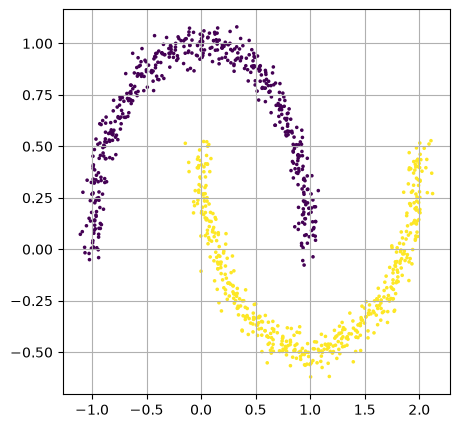

In [9]:
X, y = make_moons(n_samples = 1000, noise = 0.05, random_state = 42)
print("Shape of the data", X.shape, y.shape)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)
print("Shape of the training and testing data", X_train.shape, X_test.shape)

plt.figure(figsize = (5,5))

# s changes the level of dot details --> small number more details
plt.scatter(X[:, 0], X[:, 1], c = y, s = 2.5)
plt.grid()
plt.show()

In [10]:
svc_radial = svm.SVC(kernel = "rbf")
svc_linear = svm.SVC(kernel = "linear", C = 5)
svc_polynomial = svm.SVC(kernel = "poly", C = 10, degree = 15)

In [11]:
svc_radial.fit(X_train, y_train)
svc_linear.fit(X_train, y_train)
svc_polynomial.fit(X_train, y_train)

y_pred_radial = svc_radial.predict(X_test)
y_pred_linear = svc_linear.predict(X_test)
y_pred_polynomial = svc_polynomial.predict(X_test)

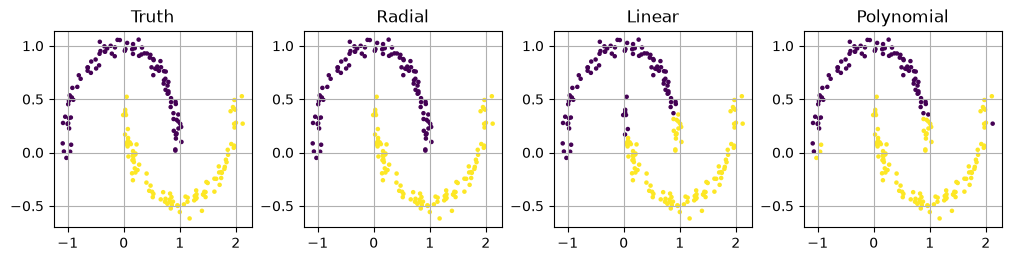

In [ ]:
panels = [
    (y_test, "Truth"),
    (y_pred_radial, "Radial"),
    (y_pred_linear, "Linear"),
    (y_pred_polynomial, "Polynomial"),
]

fig = plt.figure(figsize = (10, 2.5), constrained_layout = True)
for i, (labels, title) in enumerate(panels):
    ax = fig.add_subplot(1, 4, i + 1)
    ax.scatter(X_test[:, 0], X_test[:, 1], c = labels, s = 5)
    ax.set_title(title)
    ax.grid()
plt.show()

#### Hint about Accuracy - Where does it actually fail?

__Accuracy__ metric is a wide used metric for any kind of purpose. However it tells us _how often_ the model is wrong and never _what_ it gets wrong.

In [13]:
accuracy_radial = accuracy_score(y_true = y_test, y_pred = y_pred_radial)
accuracy_linear = accuracy_score(y_true = y_test, y_pred = y_pred_linear)
accuracy_polynomial = accuracy_score(y_true = y_test, y_pred = y_pred_polynomial)

print(f"Accuracy of: \n - Radial: {round(accuracy_radial * 100, 2)} \n - Linear: {round(accuracy_linear * 100, 2)} \n - Polynomial: {round(accuracy_polynomial * 100, 2)}")

Accuracy of: 
 - Radial: 100.0 
 - Linear: 89.0 
 - Polynomial: 91.0


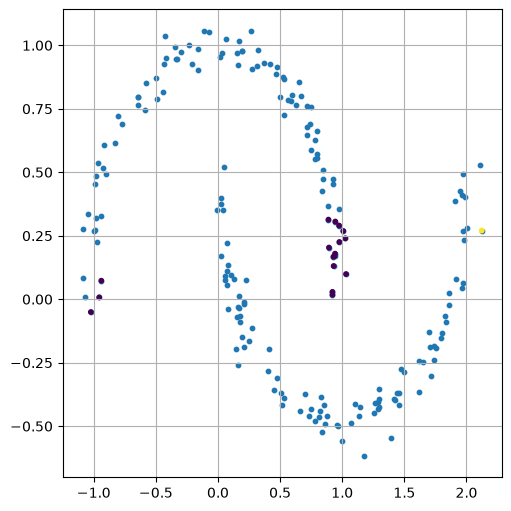

Polynomial model failed 18 predicitions over 200 test observations


In [ ]:
wrong_polynomial = np.where(y_pred_polynomial != y_test)[0]
n_show = len(wrong_polynomial)

fig = plt.figure(figsize=(5, 5), constrained_layout=True)

plt.scatter(X_test[:, 0], X_test[:, 1], s = 10)
plt.scatter(X_test[wrong_polynomial, 0], X_test[wrong_polynomial, 1], s = 10, c = y_test[wrong_polynomial])
plt.grid()
plt.show()

print(f"Polynomial model failed {n_show} predicitions over {len(y_test)} test observations")